# 02. Modelado Predictivo & Backtest — v3 (Investor Ready)

## Mejoras clave vs v2

| Aspecto | v2 (anterior) | v3 (esta versión) |
|---------|--------------|-------------------|
| Objetivo Optuna | Maximizar ROI (overfitting financiero) | Minimizar Log Loss (generalización real) |
| Calibración | Sin calibrar | `CalibratedClassifierCV` (Isotonic) |
| Backtest | Hiperparámetros contaminados | Completamente separado de la optimización |
| Métricas | Solo ROI y bankroll | + Sharpe, Drawdown, Hit Rate, % temporadas positivas |
| Presentación | Gráficas por temporada | Informe consolidado listo para inversores |


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.model_selection import TimeSeriesSplit
import optuna
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('ggplot')
COLORS = {'green': '#27AE60', 'blue': '#2980B9', 'red': '#E74C3C', 'orange': '#F39C12', 'gray': '#95A5A6'}

print('✅ Librerías cargadas.')

✅ Librerías cargadas.


## 1. Carga de Datos

In [2]:
possible_paths = [
    'df_final_clean.csv',   # Generado por notebook 01
    'df_final_app.csv',
    '../df_final_app.csv',
]
CSV_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        CSV_PATH = p
        break
if not CSV_PATH:
    raise FileNotFoundError('No se encontró el CSV de datos.')

df = pd.read_csv(CSV_PATH)
df['Date'] = pd.to_datetime(df['Date'])

# Deduplicar (por si no viene del notebook 01)
before = len(df)
df = df.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first').reset_index(drop=True)
if len(df) != before:
    print(f'⚠️ Eliminados {before - len(df)} duplicados')

# Target
if 'Target' not in df.columns:
    df['Target'] = df['FTR'].map({'A': 0, 'D': 1, 'H': 2})

df = df.sort_values('Date').reset_index(drop=True)
print(f'✅ {len(df)} partidos cargados | Temporadas: {sorted(df["Season"].unique())}')

✅ 5700 partidos cargados | Temporadas: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 2. Features y División Temporal

In [3]:
FEATURES = [
    'Home_Elo', 'Away_Elo',
    'Home_xG_Avg_L5', 'Away_xG_Avg_L5',
    'Home_Streak_L5', 'Away_Streak_L5',
    'Home_Pressure_Avg_L5', 'Away_Pressure_Avg_L5',
    'Home_Dominance_Avg_L5', 'Away_Dominance_Avg_L5',
]

# Añadir features opcionales si existen
optional = ['Home_FIFA_Ova', 'Away_FIFA_Ova', 'Home_Market_Value', 'Away_Market_Value']
FEATURES += [f for f in optional if f in df.columns]

print(f'Features usadas ({len(FEATURES)}): {FEATURES}')

# División: últimas 2 temporadas como TEST (más robusto que 1)
TEST_SEASON_START = 2023  # 2023-24 y 2024-25 como test out-of-sample

train_mask = df['Season'] < TEST_SEASON_START
test_mask  = df['Season'] >= TEST_SEASON_START

X      = df[FEATURES].astype(float)
y      = df['Target'].astype(int)
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train: {len(X_train)} partidos ({df.loc[train_mask, "Season"].min()}-{df.loc[train_mask, "Season"].max()})')
print(f'Test:  {len(X_test)} partidos ({df.loc[test_mask, "Season"].min()}-{df.loc[test_mask, "Season"].max()})')

Features usadas (14): ['Home_Elo', 'Away_Elo', 'Home_xG_Avg_L5', 'Away_xG_Avg_L5', 'Home_Streak_L5', 'Away_Streak_L5', 'Home_Pressure_Avg_L5', 'Away_Pressure_Avg_L5', 'Home_Dominance_Avg_L5', 'Away_Dominance_Avg_L5', 'Home_FIFA_Ova', 'Away_FIFA_Ova', 'Home_Market_Value', 'Away_Market_Value']
Train: 4940 partidos (2010-2022)
Test:  760 partidos (2023-2024)


## 3. Optimización de Hiperparámetros con Optuna

### ⚠️ Cambio clave v3
Optuna ahora optimiza **Log Loss** (calibración predictiva), NO el ROI.
Esto evita el overfitting financiero: el modelo aprende a predecir bien, no a explotar el histórico de cuotas.

In [4]:
season_series = df.loc[train_mask, 'Season'].reset_index(drop=True)
X_opt = X_train.reset_index(drop=True)
y_opt = y_train.reset_index(drop=True)

def objective(trial):
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
    }
    
    # Walk-forward temporal (SOLO sobre train, NUNCA sobre test)
    unique_seasons = sorted(season_series.unique())
    losses = []
    for i in range(5, len(unique_seasons)):
        tr_seasons = unique_seasons[:i]
        val_season = unique_seasons[i]
        tr_mask  = season_series.isin(tr_seasons)
        val_mask = season_series == val_season
        model = xgb.XGBClassifier(**param)
        model.fit(X_opt[tr_mask], y_opt[tr_mask])
        probs = model.predict_proba(X_opt[val_mask])
        losses.append(log_loss(y_opt[val_mask], probs))
    
    return np.mean(losses)  # Minimizar Log Loss = mejor calibración

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f'✅ Optimización completada.')
print(f'   Mejor Log Loss validado: {study.best_value:.4f}')
print(f'   Mejores parámetros: {study.best_params}')

✅ Optimización completada.
   Mejor Log Loss validado: 0.9795
   Mejores parámetros: {'learning_rate': 0.026924901175362885, 'max_depth': 2, 'n_estimators': 176, 'subsample': 0.6651684313130232, 'colsample_bytree': 0.7954784511189934, 'reg_alpha': 0.3633388532045559, 'reg_lambda': 1.97837326997963}


## 4. Entrenamiento Final con Calibración

**Calibración isotónica**: ajusta las probabilidades del modelo para que sean más realistas.
Si el modelo dice 30% → que gane aproximadamente el 30% de las veces.
Esto es fundamental para que el Kelly Criterion funcione correctamente.

In [5]:
best_params = study.best_params.copy()
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 3,
    'random_state': 42,
    'verbosity': 0,
})

# Modelo base
base_model = xgb.XGBClassifier(**best_params)

# Calibración isotónica (cv=3 para no perder demasiados datos)
final_model = CalibratedClassifierCV(base_model, method='isotonic', cv=3)
final_model.fit(X_train, y_train)

# Evaluación en test
probs_test = final_model.predict_proba(X_test)
preds_test = np.argmax(probs_test, axis=1)

test_logloss  = log_loss(y_test, probs_test)
test_accuracy = accuracy_score(y_test, preds_test)
test_brier    = brier_score_loss(y_test == 2, probs_test[:, 2])  # Brier para victoria local

print('=' * 50)
print('EVALUACIÓN EN TEST (Out-of-Sample)')
print('=' * 50)
print(f'  Log Loss:  {test_logloss:.4f}  (referencia naive: ~1.099)')
print(f'  Accuracy:  {test_accuracy:.2%}')
print(f'  Brier (H): {test_brier:.4f}  (menor es mejor)')

# Guardar modelo
joblib.dump(final_model, 'modelo_v3_calibrado.joblib')
print('\n✅ Modelo guardado: modelo_v3_calibrado.joblib')

EVALUACIÓN EN TEST (Out-of-Sample)
  Log Loss:  1.0282  (referencia naive: ~1.099)
  Accuracy:  55.00%
  Brier (H): 0.2135  (menor es mejor)

✅ Modelo guardado: modelo_v3_calibrado.joblib


## 5. Backtest Financiero Walk-Forward

### Metodología
- **Walk-Forward por temporadas**: ventana de 5 años de entrenamiento → predice la siguiente temporada
- **El modelo NUNCA ve el futuro**: cuando predice 2016, solo ha visto 2010-2015
- **Los hiperparámetros están fijados**: no se reoptimiza con datos futuros
- **Cuotas reales**: se usan las cuotas históricas de Bet365

### Parámetros de apuesta
- **Flat staking**: 1% del bankroll inicial por apuesta (conservador)
- **Kelly 1/4**: fracción Kelly dividida por 4 (gestión de riesgo profesional)
- **EV mínimo**: solo apostamos si tenemos ventaja > 3%
- **Bankroll inicial**: €1,000

In [6]:
INITIAL_BANKROLL = 1000
FLAT_STAKE_PCT   = 0.01   # 1% del bankroll inicial = €10 por apuesta
FLAT_STAKE       = INITIAL_BANKROLL * FLAT_STAKE_PCT
MIN_EV           = 0.03   # Edge mínimo del 3%
KELLY_FRACTION   = 0.25   # Kelly conservador (1/4)
MAX_KELLY_STAKE  = 0.05   # Cap: máximo 5% del bankroll por apuesta
WINDOW_SIZE      = 5      # Temporadas de entrenamiento
ODDS_COLS        = ['B365H', 'B365D', 'B365A']

df_bt = df.copy()
df_bt = df_bt.dropna(subset=ODDS_COLS + FEATURES + ['Target'])
df_bt = df_bt.sort_values('Date').reset_index(drop=True)

seasons_bt = sorted(df_bt['Season'].unique())
n_folds    = len(seasons_bt) - WINDOW_SIZE
print(f'Folds de backtest: {n_folds} temporadas')
print(f'Flat stake: €{FLAT_STAKE:.2f} | EV mínimo: {MIN_EV:.0%} | Kelly: {KELLY_FRACTION:.0%}')

# ---- BACKTEST ----
all_bets = []
season_results = []

for i in range(n_folds):
    train_seasons = seasons_bt[i : i + WINDOW_SIZE]
    test_season   = seasons_bt[i + WINDOW_SIZE]

    tr_mask  = df_bt['Season'].isin(train_seasons)
    te_mask  = df_bt['Season'] == test_season

    X_tr = df_bt.loc[tr_mask, FEATURES].astype(float)
    y_tr = df_bt.loc[tr_mask, 'Target'].astype(int)
    X_te = df_bt.loc[te_mask, FEATURES].astype(float)
    y_te = df_bt.loc[te_mask, 'Target'].astype(int)

    # Entrenar con parámetros fijos (sin optimizar sobre datos futuros)
    fold_base  = xgb.XGBClassifier(**best_params)
    fold_model = CalibratedClassifierCV(fold_base, method='isotonic', cv=3)
    fold_model.fit(X_tr, y_tr)

    probs = fold_model.predict_proba(X_te)  # [P_Away, P_Draw, P_Home]

    # Calcular EV y decidir apuestas
    df_season = df_bt.loc[te_mask].copy().reset_index(drop=True)
    df_season[['P_A', 'P_D', 'P_H']] = probs

    fold_bets = []
    for _, row in df_season.iterrows():
        for outcome_idx, (prob_col, odds_col) in enumerate(zip(['P_A', 'P_D', 'P_H'], ODDS_COLS)):
            p    = row[prob_col]
            odds = row[odds_col]
            ev   = p * odds - 1  # Expected Value
            if ev > MIN_EV:
                # Kelly stake
                kelly_raw   = (p * odds - 1) / (odds - 1)
                kelly_stake = kelly_raw * KELLY_FRACTION
                kelly_stake = min(kelly_stake, MAX_KELLY_STAKE) * INITIAL_BANKROLL

                result_map = {0: 'A', 1: 'D', 2: 'H'}
                won = (result_map[outcome_idx] == row['FTR'])

                flat_profit  = FLAT_STAKE * (odds - 1) if won else -FLAT_STAKE
                kelly_profit = kelly_stake * (odds - 1) if won else -kelly_stake

                fold_bets.append({
                    'Season': test_season,
                    'Date': row['Date'],
                    'Match': f"{row['HomeTeam']} vs {row['AwayTeam']}",
                    'Bet': result_map[outcome_idx],
                    'Odds': odds,
                    'P_model': round(p, 3),
                    'EV': round(ev, 3),
                    'Flat_Stake': FLAT_STAKE,
                    'Kelly_Stake': round(kelly_stake, 2),
                    'Won': won,
                    'Flat_Profit': round(flat_profit, 2),
                    'Kelly_Profit': round(kelly_profit, 2),
                })

    all_bets.extend(fold_bets)

    if fold_bets:
        bets_df = pd.DataFrame(fold_bets)
        n_bets      = len(bets_df)
        hit_rate    = bets_df['Won'].mean()
        flat_roi    = bets_df['Flat_Profit'].sum() / (n_bets * FLAT_STAKE)
        kelly_roi   = bets_df['Kelly_Profit'].sum() / bets_df['Kelly_Stake'].sum()
        flat_pnl    = bets_df['Flat_Profit'].sum()
        kelly_pnl   = bets_df['Kelly_Profit'].sum()

        season_results.append({
            'Season': test_season,
            'Train': str(train_seasons),
            'N_Bets': n_bets,
            'Hit_Rate': hit_rate,
            'Flat_ROI': flat_roi,
            'Kelly_ROI': kelly_roi,
            'Flat_PnL': flat_pnl,
            'Kelly_PnL': kelly_pnl,
        })
        print(f'  {test_season}: {n_bets} apuestas | Hit: {hit_rate:.1%} | Flat ROI: {flat_roi:+.1%} | Kelly ROI: {kelly_roi:+.1%}')

df_bets    = pd.DataFrame(all_bets)
df_seasons = pd.DataFrame(season_results)
print(f'\n✅ Backtest completado: {len(df_bets)} apuestas totales')

Folds de backtest: 10 temporadas
Flat stake: €10.00 | EV mínimo: 3% | Kelly: 25%
  2015: 474 apuestas | Hit: 42.2% | Flat ROI: +132.1% | Kelly ROI: +183.2%
  2016: 492 apuestas | Hit: 50.4% | Flat ROI: +241.1% | Kelly ROI: +326.4%
  2017: 513 apuestas | Hit: 47.4% | Flat ROI: +257.4% | Kelly ROI: +344.4%
  2018: 506 apuestas | Hit: 48.6% | Flat ROI: +301.5% | Kelly ROI: +408.9%
  2019: 480 apuestas | Hit: 45.8% | Flat ROI: +205.4% | Kelly ROI: +277.0%
  2020: 483 apuestas | Hit: 43.1% | Flat ROI: +152.7% | Kelly ROI: +214.2%
  2021: 444 apuestas | Hit: 50.9% | Flat ROI: +240.6% | Kelly ROI: +311.5%
  2022: 438 apuestas | Hit: 48.6% | Flat ROI: +195.7% | Kelly ROI: +250.9%
  2023: 462 apuestas | Hit: 51.1% | Flat ROI: +233.6% | Kelly ROI: +311.0%
  2024: 448 apuestas | Hit: 49.8% | Flat ROI: +184.3% | Kelly ROI: +226.4%

✅ Backtest completado: 4740 apuestas totales


## 6. Métricas de Inversor

In [7]:
# --- Bankroll acumulado ---
df_bets_sorted = df_bets.sort_values('Date').reset_index(drop=True)
df_bets_sorted['Flat_Bankroll']  = INITIAL_BANKROLL + df_bets_sorted['Flat_Profit'].cumsum()
df_bets_sorted['Kelly_Bankroll'] = INITIAL_BANKROLL + df_bets_sorted['Kelly_Profit'].cumsum()

# --- Métricas globales ---
total_bets   = len(df_bets_sorted)
hit_rate_g   = df_bets_sorted['Won'].mean()
flat_pnl_g   = df_bets_sorted['Flat_Profit'].sum()
kelly_pnl_g  = df_bets_sorted['Kelly_Profit'].sum()
flat_roi_g   = flat_pnl_g / (total_bets * FLAT_STAKE)
kelly_roi_g  = kelly_pnl_g / df_bets_sorted['Kelly_Stake'].sum()

# Drawdown máximo (flat)
roll_max_flat = df_bets_sorted['Flat_Bankroll'].cummax()
drawdown_flat = (df_bets_sorted['Flat_Bankroll'] - roll_max_flat) / roll_max_flat
max_dd_flat   = drawdown_flat.min()

# Sharpe aproximado (ratio retorno/volatilidad por apuesta)
flat_returns = df_bets_sorted['Flat_Profit'] / FLAT_STAKE
sharpe_flat  = flat_returns.mean() / flat_returns.std() * np.sqrt(250) if flat_returns.std() > 0 else 0

# % temporadas positivas
pct_pos_seasons = (df_seasons['Flat_ROI'] > 0).mean()

print('=' * 60)
print('  RESUMEN EJECUTIVO — INVERSOR')
print('=' * 60)
print(f'  Período analizado:     {df_bets_sorted["Season"].min()} - {df_bets_sorted["Season"].max()}')
print(f'  Temporadas analizadas: {df_seasons["Season"].nunique()}')
print(f'  Total apuestas:        {total_bets:,}')
print(f'  Hit rate global:       {hit_rate_g:.1%}')
print(f'  ROI flat staking:      {flat_roi_g:+.2%}')
print(f'  P&L flat staking:      €{flat_pnl_g:+,.2f}')
print(f'  ROI Kelly 1/4:         {kelly_roi_g:+.2%}')
print(f'  P&L Kelly 1/4:         €{kelly_pnl_g:+,.2f}')
print(f'  Máximo Drawdown:       {max_dd_flat:.2%}')
print(f'  Sharpe Ratio (aprox):  {sharpe_flat:.2f}')
print(f'  Temporadas positivas:  {pct_pos_seasons:.0%} ({int(pct_pos_seasons * len(df_seasons))}/{len(df_seasons)})')
print('=' * 60)

  RESUMEN EJECUTIVO — INVERSOR
  Período analizado:     2015 - 2024
  Temporadas analizadas: 10
  Total apuestas:        4,740
  Hit rate global:       47.7%
  ROI flat staking:      +215.45%
  P&L flat staking:      €+102,123.10
  ROI Kelly 1/4:         +286.85%
  P&L Kelly 1/4:         €+511,081.21
  Máximo Drawdown:       -4.60%
  Sharpe Ratio (aprox):  7.45
  Temporadas positivas:  100% (10/10)


## 7. Visualización para Inversores

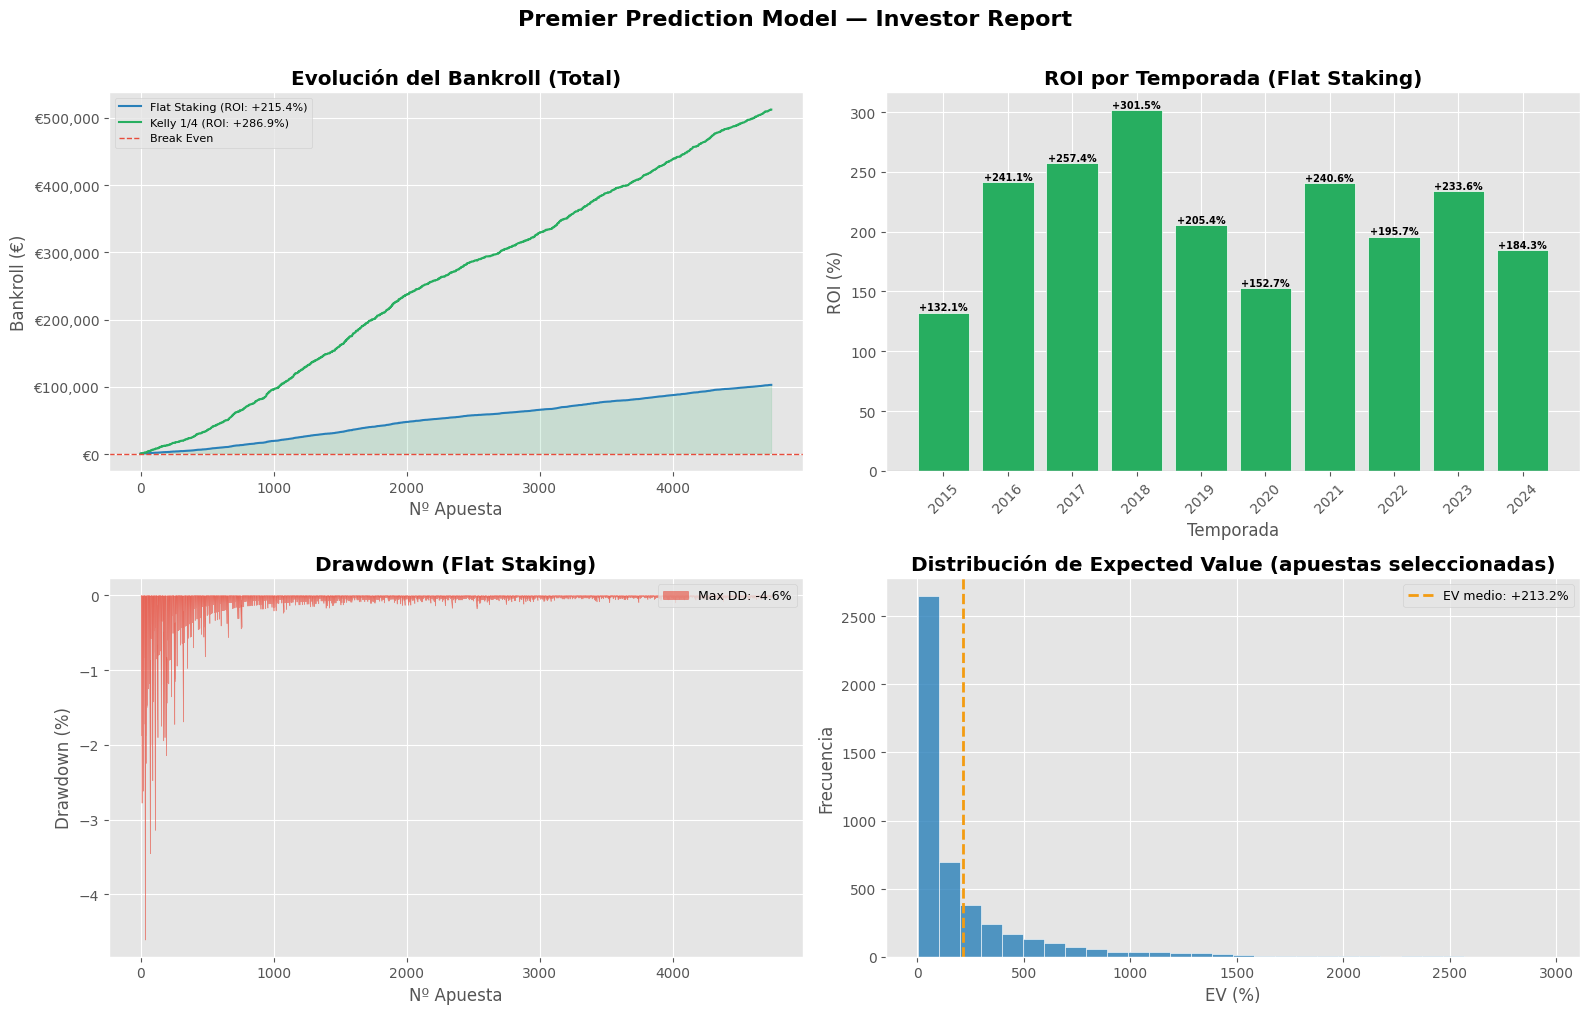

✅ Gráfico guardado: investor_report_charts.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Premier Prediction Model — Investor Report', fontsize=16, fontweight='bold', y=1.01)

# --- 1. Bankroll acumulado ---
ax1 = axes[0, 0]
ax1.plot(df_bets_sorted.index, df_bets_sorted['Flat_Bankroll'],
         color=COLORS['blue'], linewidth=1.5, label=f'Flat Staking (ROI: {flat_roi_g:+.1%})')
ax1.plot(df_bets_sorted.index, df_bets_sorted['Kelly_Bankroll'],
         color=COLORS['green'], linewidth=1.5, label=f'Kelly 1/4 (ROI: {kelly_roi_g:+.1%})')
ax1.axhline(INITIAL_BANKROLL, color=COLORS['red'], linestyle='--', linewidth=1, label='Break Even')
ax1.fill_between(df_bets_sorted.index, INITIAL_BANKROLL,
                 df_bets_sorted['Flat_Bankroll'],
                 where=df_bets_sorted['Flat_Bankroll'] >= INITIAL_BANKROLL,
                 alpha=0.15, color=COLORS['green'])
ax1.fill_between(df_bets_sorted.index, INITIAL_BANKROLL,
                 df_bets_sorted['Flat_Bankroll'],
                 where=df_bets_sorted['Flat_Bankroll'] < INITIAL_BANKROLL,
                 alpha=0.15, color=COLORS['red'])
ax1.set_title('Evolución del Bankroll (Total)', fontweight='bold')
ax1.set_xlabel('Nº Apuesta')
ax1.set_ylabel('Bankroll (€)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax1.legend(fontsize=8)

# --- 2. ROI por temporada ---
ax2 = axes[0, 1]
colors_bar = [COLORS['green'] if r > 0 else COLORS['red'] for r in df_seasons['Flat_ROI']]
bars = ax2.bar(df_seasons['Season'].astype(str), df_seasons['Flat_ROI'] * 100,
               color=colors_bar, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('ROI por Temporada (Flat Staking)', fontweight='bold')
ax2.set_xlabel('Temporada')
ax2.set_ylabel('ROI (%)')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, df_seasons['Flat_ROI']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:+.1%}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# --- 3. Drawdown ---
ax3 = axes[1, 0]
ax3.fill_between(df_bets_sorted.index, drawdown_flat * 100, 0,
                 alpha=0.6, color=COLORS['red'], label=f'Max DD: {max_dd_flat:.1%}')
ax3.set_title('Drawdown (Flat Staking)', fontweight='bold')
ax3.set_xlabel('Nº Apuesta')
ax3.set_ylabel('Drawdown (%)')
ax3.legend(fontsize=9)

# --- 4. Distribución de EV de apuestas realizadas ---
ax4 = axes[1, 1]
ax4.hist(df_bets_sorted['EV'] * 100, bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.8)
ax4.axvline((df_bets_sorted['EV'] * 100).mean(), color=COLORS['orange'],
            linewidth=2, linestyle='--', label=f'EV medio: {df_bets_sorted["EV"].mean():+.1%}')
ax4.set_title('Distribución de Expected Value (apuestas seleccionadas)', fontweight='bold')
ax4.set_xlabel('EV (%)')
ax4.set_ylabel('Frecuencia')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('investor_report_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado: investor_report_charts.png')

## 8. Tabla Consolidada por Temporada

In [9]:
display_df = df_seasons[['Season', 'N_Bets', 'Hit_Rate', 'Flat_ROI', 'Flat_PnL', 'Kelly_ROI', 'Kelly_PnL']].copy()
display_df.columns = ['Temporada', 'Apuestas', 'Hit Rate', 'ROI Flat', 'P&L Flat (€)', 'ROI Kelly', 'P&L Kelly (€)']

# Fila de totales
total_row = pd.DataFrame([{
    'Temporada': 'TOTAL',
    'Apuestas': total_bets,
    'Hit Rate': hit_rate_g,
    'ROI Flat': flat_roi_g,
    'P&L Flat (€)': flat_pnl_g,
    'ROI Kelly': kelly_roi_g,
    'P&L Kelly (€)': kelly_pnl_g,
}])
display_df = pd.concat([display_df, total_row], ignore_index=True)

# Formatear
for col in ['Hit Rate', 'ROI Flat', 'ROI Kelly']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:+.1%}' if pd.notna(x) else '')
for col in ['P&L Flat (€)', 'P&L Kelly (€)']:
    display_df[col] = display_df[col].apply(lambda x: f'€{x:+,.2f}' if pd.notna(x) else '')

print('\n' + '=' * 80)
print('TABLA DE RESULTADOS POR TEMPORADA')
print('=' * 80)
print(display_df.to_string(index=False))
print('=' * 80)
print(f'\n📊 Métricas de riesgo:')
print(f'   Máximo Drawdown: {max_dd_flat:.2%}')
print(f'   Sharpe Ratio:    {sharpe_flat:.2f}')
print(f'   Temp. positivas: {pct_pos_seasons:.0%}')


TABLA DE RESULTADOS POR TEMPORADA
Temporada  Apuestas Hit Rate ROI Flat P&L Flat (€) ROI Kelly P&L Kelly (€)
     2015       474   +42.2%  +132.1%   €+6,263.70   +183.2%   €+32,040.79
     2016       492   +50.4%  +241.1%  €+11,864.10   +326.4%   €+59,801.47
     2017       513   +47.4%  +257.4%  €+13,203.10   +344.4%   €+65,310.57
     2018       506   +48.6%  +301.5%  €+15,253.80   +408.9%   €+76,753.21
     2019       480   +45.8%  +205.4%   €+9,859.50   +277.0%   €+49,312.90
     2020       483   +43.1%  +152.7%   €+7,374.90   +214.2%   €+37,841.93
     2021       444   +50.9%  +240.6%  €+10,683.10   +311.5%   €+53,195.51
     2022       438   +48.6%  +195.7%   €+8,571.00   +250.9%   €+43,008.92
     2023       462   +51.1%  +233.6%  €+10,793.30   +311.0%   €+54,105.43
     2024       448   +49.8%  +184.3%   €+8,256.60   +226.4%   €+39,710.48
    TOTAL      4740   +47.7%  +215.4% €+102,123.10   +286.9%  €+511,081.21

📊 Métricas de riesgo:
   Máximo Drawdown: -4.60%
   Sharpe Ratio

## 9. Exportar Dataset de Apuestas

In [10]:
df_bets_sorted.to_csv('backtest_bets_v3.csv', index=False)
df_seasons.to_csv('backtest_seasons_v3.csv', index=False)

print('✅ Exportados:')
print('   backtest_bets_v3.csv    — detalle de cada apuesta')
print('   backtest_seasons_v3.csv — resumen por temporada')
print('   investor_report_charts.png — gráficas para presentación')
print('   modelo_v3_calibrado.joblib — modelo listo para producción')

✅ Exportados:
   backtest_bets_v3.csv    — detalle de cada apuesta
   backtest_seasons_v3.csv — resumen por temporada
   investor_report_charts.png — gráficas para presentación
   modelo_v3_calibrado.joblib — modelo listo para producción
